# Collide2v challenges: Introduction

This notebook gives a basic introduction to the COLLIDE2V (COmprehensive Lhc coLlision Dataset for Foundation model dEvelopment) open-access high energy physics dataset. There are three hackathon challenges that use this dataset: 

-  Challenge 1: Di-Higgs (HH→4b vs. QCD) discrimination for trigger systems
-   Challenge 2: Collider Data Foundation Model Pre-training and Online Adaptation
-   Challenge 3: Robust Tagging and Self-adapting Trigger Systems Under Changing Detector Conditions

For the purposes of this hackathon we have created subsets of the original 750 million event dataset for use in each challenge. Each subset contains data from physics processes and variables related to that particular challenge. The data is stored as `parquet` files (in subdirectories per process) and organized into training and evaluation datasets. 

```bash
#location of each dataset:
#Challenge 1:
/hack-data/C1_HH4b/train/
/hack-data/C1_HH4b/eval/

#Challenge 2:
/hack-data/C5_foundation_model/train/
/hack-data/C5_foundation_model/eval/

#Challenge 3:
/hack-data/C9_robust_tagging/train/
/hack-data/C9_robust_tagging/eval/
```

This introductory notebook shows how to load these datasets and make a basic model. It uses a small subset of the Challenge 1 data for demonstration purposes, and is based on [Chris Brown's original notebook](https://github.com/Chriisbrown/FastML_tutorial/blob/main/ML_LHC_tutorial.ipynb). 

**Please note:** This example is in pytorch, but if you would rather use tensorflow/keras the [original notebook](https://github.com/Chriisbrown/FastML_tutorial/blob/main/ML_LHC_tutorial.ipynb) does the same exercise using those packages instead. The dataloading in that notebook should be replaced with the hackathon-specific example here if you use it. A copy of that notebook is included for reference in this gitrepo for convenience. 

## Getting Started

In this tutorial, we explore a realistic LHC dataset composed of a **signal sample**: di-Higgs production

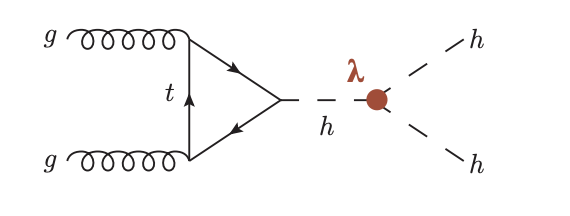

and several high cross-section **background processes** that dominate LHC datasets:

- **QCD multi-jet production**  
- **Top quark pair production** with fully hadronic decays  
- **W boson production** with hadronic decays  

Our goal is to train machine learning models to classify these processes using **all reconstructed particles in each event**.  

Each particle comes with a set of features, including **kinematics, particle ID, and displacement from the primary vertex**. Consequently, the input tensors for our models have shape:

$$
[N_\text{events}, N_\text{particles}, N_\text{particle features}]
$$

We will train and compare a few types of models:

---

### 1. Classic MLP

Uses flattened inputs for all particles in an event.  



### 2. DeepSet

This architecture introduces an **inductive bias that respects permutation symmetry**, meaning the output is invariant to the order of particles in the event.  

Each particle is first embedded individually through a shared function $\phi$:

$$
h_i = \phi(x_i), \quad i = 1, \dots, N_\text{particles}
$$

These embeddings are then **aggregated using a permutation-invariant operation**, typically summation, mean, or max:

$$
H = \rho\Big( \sum_{i=1}^{N_\text{particles}} h_i \Big)
$$

where $\rho$ is a function (often a small feed-forward network) that maps the aggregated embedding to the output, e.g., class probabilities.  

Throughout this tutorial, we justify architectural choices using principles from learning theory and provide references to relevant papers where appropriate.

In [1]:
#first some imports
import glob
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
# import torch
# import torch.nn as nn

import keras
from keras import layers, models, regularizers
from keras.optimizers import Adam
from keras.optimizers.schedules import CosineDecay
from keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
from keras.models import load_model
from keras import Model

from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# seed = 0
# np.random.seed(seed)
# torch.manual_seed(seed)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

2026-09-04 12:55:04.418559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-04 12:55:04.439266: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-04 12:55:04.445590: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-04 12:55:04.461171: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-04 12:55:05.443916: W tensorflow/compiler/tf2

## Load the dataset

This example uses a small chunk of the C1_HH4b data, but all of the collide2v based datasets can be loaded similarly. It contains HH->bbbb signal events, and QCD, W+Jets and TT background events.

In [2]:
#load 3000 events per process
DATA_ROOT = Path("../hack-data/C1_HH4b/train")
N_EVENTS_PER_SAMPLE = 3000   # small subset per process -- bump this up once you trust the pipeline
N_PARTICLES_MAX = 16        # candidates kept per event (truncate/zero-pad), matches the original tutorial
CAND_FIELDS = ["pt", "eta", "phi", "dxy"]

SAMPLES = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())
print("Samples found:", SAMPLES)

Samples found: ['HH_4b', 'QCD_HT250toInf', 'WJetsToLNu_13TeV-madgraphMLM-pythia8', 'WJetsToQQ_13TeV-madgraphMLM-pythia8', 'tt0123j_5f_ckm_LO_MLM_hadronic', 'tt0123j_5f_ckm_LO_MLM_leptonic', 'tt0123j_5f_ckm_LO_MLM_semiLeptonic']


In [3]:
# Read in just the first N events of a sample's first train fragment
def read_first_fragment(sample_dir: Path, n_events: int) -> ak.Array:
    frag = sorted(sample_dir.glob(f"{sample_dir.name}_*.parquet"))[0]
    pf = pq.ParquetFile(frag)
    batch = next(pf.iter_batches(batch_size=n_events, columns=["L1T_PUPPIPart", "label"]))
    return ak.from_arrow(batch)

# Reorganize the data into (N_events, N_particles, N_features) padded tensors (not variable length)
def load_physics_dataset_from_pvc(samples, n_events_per_sample=N_EVENTS_PER_SAMPLE,
                                   n_particles_max=N_PARTICLES_MAX, fields=CAND_FIELDS):
    X_parts, y_parts = [], []

    for sample in samples:
        arr = read_first_fragment(DATA_ROOT / sample, n_events_per_sample)
        cands = arr["L1T_PUPPIPart"]
        labels = ak.to_numpy(arr["label"])

        per_field = []
        for f in fields:
            padded = ak.pad_none(cands[f], n_particles_max, clip=True, axis=1)
            per_field.append(ak.to_numpy(ak.fill_none(padded, 0.0)).astype(np.float32))
        # each entry in per_field is (N_events, N_particles) -> stack into (N_events, N_particles, N_features)
        sample_X = np.stack(per_field, axis=-1)

        X_parts.append(sample_X)
        y_parts.append(labels)
        print(f"{sample}: loaded {len(arr)} events, label={labels[0]}")

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts, axis=0).astype(np.int64)
    return X, y


X, y = load_physics_dataset_from_pvc(SAMPLES)
print(X.shape, y.shape)  # (N_total_events, N_particles, N_features), (N_total_events,)
print("Class counts:", {int(c): int((y == c).sum()) for c in np.unique(y)})

HH_4b: loaded 3000 events, label=1
QCD_HT250toInf: loaded 3000 events, label=0
WJetsToLNu_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
WJetsToQQ_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
tt0123j_5f_ckm_LO_MLM_hadronic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_leptonic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_semiLeptonic: loaded 3000 events, label=2
(21000, 16, 4) (21000,)
Class counts: {0: 3000, 1: 3000, 2: 9000, 3: 6000}


## Visualize the data

Let's see what is in our data! Our collider events contain collections of objects: particles (`PUPPIPart`), electrons, muons, small radius ("ak4") jets, large radius ("ak8") jets... 

Each of these collections have different numbers of objects. The data stores up to 500 reconstructed particles in an event, but only up to 5 electrons for example.

The `label` object contains different labels based on event type:

- 0 = QCD (QCD_HT250toInf) background
- 1 = HH_4b (the di-Higgs signal)
- 2 = ttbar background (optional) (merges all three: tt_hadronic, tt_semiLeptonic, tt_leptonic)
- 3 = W+jets background (optional) (merges both: WJetsToLNu, WJetsToQQ)

In [4]:
#let's see all the collections stored in our events
frag = sorted((DATA_ROOT / "HH_4b").glob("HH_4b_*.parquet"))[0]
full = ak.from_arrow(next(pq.ParquetFile(frag).iter_batches(batch_size=5)))
full.fields

['L1T_Electron',
 'L1T_JetAK4',
 'L1T_JetAK8',
 'L1T_MuonTight',
 'L1T_PhotonTight',
 'L1T_JetPuppiAK4',
 'L1T_JetPuppiAK8',
 'L1T_MET',
 'L1T_PUPPIMET',
 'L1T_ScalarHT',
 'Event',
 'L1T_PUPPIPart',
 'label',
 'source_file',
 'source_row']

Let's go one level deeper and see what is stored in the reconstructed particles `L1_PUPPIPart`: Note this object collection is called `PUPPIPart` - these are the same as `PFPart` in the original notebook, they just include some extra pile-up weights that the `PFPart` collection doesnt have.

In [5]:
# what is stored in the reconstructed particles `L1_PUPPIPart?
hh4b_frag = read_first_fragment(DATA_ROOT / "HH_4b", 1) #just one event
hh4b_frag["L1T_PUPPIPart"].fields 

['pt',
 'eta',
 'phi',
 'dxy',
 'dxysig',
 'pdgId',
 'charge',
 'pt_weighted',
 'puppi_weight',
 'e',
 'mass',
 'dz',
 'error_dz',
 'funique_id']

In [6]:
#make a table of these features to see some of their values 
ak.to_dataframe(hh4b_frag["L1T_PUPPIPart"][:5])

pt       eta       phi       dxy    dxysig  pdgId  \
entry subentry                                                             
0     0         31.015625 -0.142578  2.445312  0.000000   0.00000      0   
      1         27.859375 -1.784180 -1.127930  0.000113   1.12793     13   
      2         14.164062  2.173828 -1.049805  0.000000   0.00000     22   
      3         14.007812 -0.313232  2.527344  0.000000   0.00000     22   
      4         12.179688 -1.968750 -1.166992 -0.003944 -39.43750    211   
...                   ...       ...       ...       ...       ...    ...   
      464        1.478516  2.902344 -1.278320  0.000000   0.00000      0   
      465        1.476562 -2.498047 -1.086914  0.000000   0.00000      0   
      466        1.476562 -1.434570  0.286865  0.000000   0.00000     22   
      467        1.475586  1.250000  0.091309  0.000000   0.00000      0   
      468        1.473633 -0.975586  2.564453  0.000000   0.00000      0   

                charge  pt_weighted  puppi_weight          e          mass  \
entry subentry                                                               
0     0              0     9.671875      0.311768  31.343750  3.576279e-07   
      1              1    27.859375      1.000000  85.250000  1.056519e-01   
      2              0     0.000000      0.000000  63.093750  1.370907e-06   
      3              0     5.136719      0.366699  14.695312  0.000000e+00   
      4             -1    12.179688      1.000000  44.500000  1.395264e-01   
...                ...          ...           ...        ...           ...   
      464            0     0.000000      0.000000  13.515625  2.384186e-07   
      465            0     0.000000      0.000000   9.031250 -1.192093e-07   
      466            0     0.000000      0.000000   3.273438  5.960464e-08   
      467            0     0.000000      0.000000   2.787109 -0.000000e+00   
      468            0     0.000000      0.000000   2.232422 -5.960464e-08   

                     dz  error_dz  funique_id  
entry subentry                                 
0     0          0.0000       0.0       92489  
      1         46.7500       0.0       74821  
      2          0.0000       0.0       90768  
      3          0.0000       0.0       90254  
      4         46.8125       0.0       89169  
...                 ...       ...         ...  
      464        0.0000       0.0       93258  
      465        0.0000       0.0       92039  
      466        0.0000       0.0       90049  
      467        0.0000       0.0       92611  
      468        0.0000       0.0       92430  

[469 rows x 14 columns]

Let's use the reconstructed particles to create an event display of one HH->bbbb signal event to visualize what these particles look like within a cylindrical particle detector:

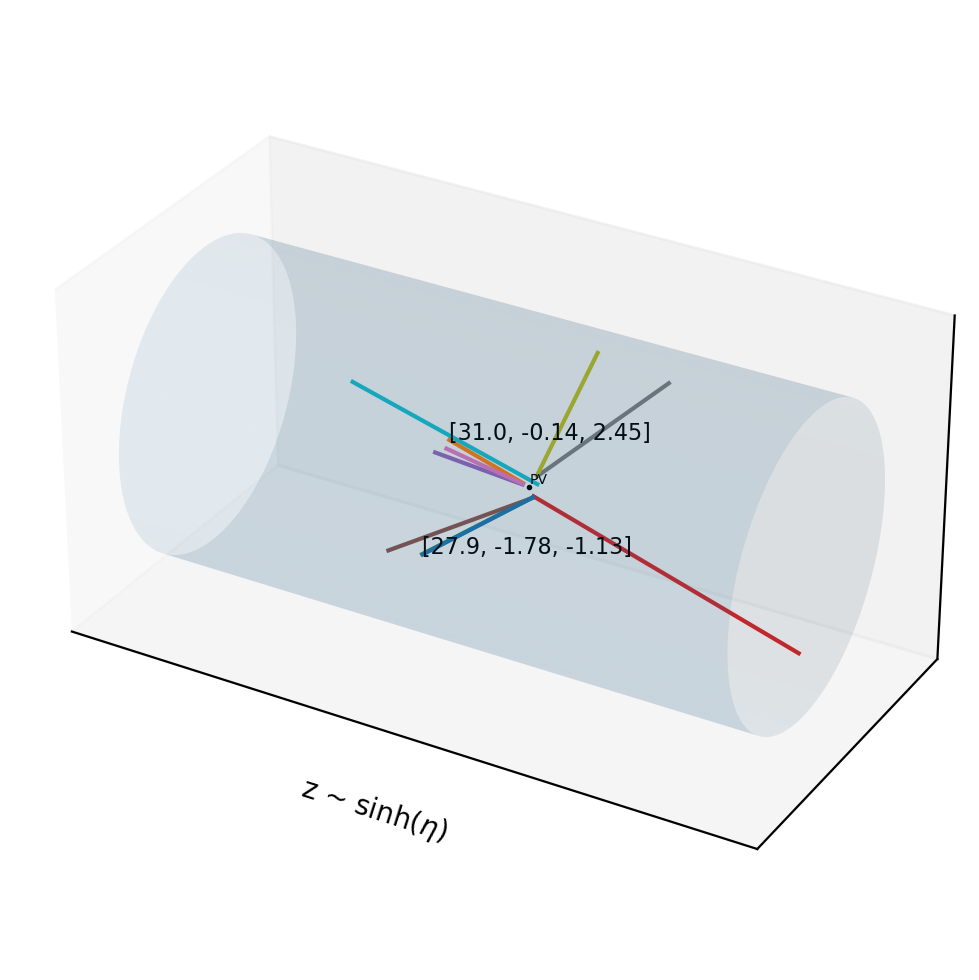

In [7]:
def plot_event_display(pt, eta, phi, dxy):
    idx = np.argsort(pt)[-10:][::-1]
    eta, phi, pt, dxy = eta[idx], phi[idx], pt[idx], dxy[idx]

    R = 1.0
    d0_scale = 0.1
    x_end = np.sinh(eta)
    y_start = d0_scale * np.cos(phi)
    z_start = d0_scale * np.sin(phi)
    y_end = y_start + R * np.cos(phi)
    z_end = z_start + R * np.sin(phi)

    fig = plt.figure(figsize=(7, 5), dpi=200)
    ax = fig.add_subplot(projection="3d")

    phi_grid = np.linspace(0, 2 * np.pi, 100)
    x_grid = np.linspace(x_end.min() * 1.2, x_end.max() * 1.2, 100)
    Phi, Xg = np.meshgrid(phi_grid, x_grid)
    ax.plot_surface(Xg, R * np.cos(Phi), R * np.sin(Phi), alpha=0.1)

    for i, (xs, ys, zs, xe, ye, ze, et, ph, p) in enumerate(
        zip(np.zeros_like(x_end), y_start, z_start, x_end, y_end, z_end, eta, phi, pt)
    ):
        ax.plot([xs, xe], [ys, ye], [zs, ze])
        if i in (0, 1):
            ax.text(xe, ye, ze, f"[{p:.1f}, {et:.2f}, {ph:.2f}]", fontsize=8)

    ax.scatter(0, 0, 0, color="black", s=1)
    ax.text(0, 0, 0, "PV", color="black", fontsize=5, ha="left", va="bottom")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(r"z ~ sinh($\eta$)")
    ax.set_box_aspect((2, 1, 1))
    plt.tight_layout()
    plt.show()

c0 = hh4b_frag["L1T_PUPPIPart"][0]
plot_event_display(ak.to_numpy(c0["pt"]), ak.to_numpy(c0["eta"]), ak.to_numpy(c0["phi"]), ak.to_numpy(c0["dxy"]))

## Preprocess the data

Let's normalize and preprocess the data and sort it into train and test sets to make some basic models. 

In [8]:
#preprocess and normalize etc the data
def preprocess_particles(X, pt_index=0, eta_index=1, phi_index=2, d0_index=3, eta_range=(-5.0, 5.0)):
    X_proc = X.copy()

    pt = X_proc[:, :, pt_index]
    pt_logged = np.log(pt + 1.0)
    pt_min, pt_max = pt_logged.min(), pt_logged.max()
    X_proc[:, :, pt_index] = (pt_logged - pt_min) / (pt_max - pt_min + 1e-8)

    eta_min, eta_max = eta_range
    X_proc[:, :, eta_index] = np.clip((X_proc[:, :, eta_index] - eta_min) / (eta_max - eta_min), 0.0, 1.0)

    d0 = X_proc[:, :, d0_index]
    d0_min, d0_max = d0.min(), d0.max()
    X_proc[:, :, d0_index] = (d0 - d0_min) / (d0_max - d0_min + 1e-8)

    phi = X_proc[:, :, phi_index]
    phi_cos, phi_sin = np.cos(phi), np.sin(phi)
    X_proc = np.delete(X_proc, phi_index, axis=2)
    X_proc = np.concatenate([X_proc, phi_cos[..., np.newaxis], phi_sin[..., np.newaxis]], axis=2)
    return X_proc


X_proc = preprocess_particles(X)
print(X_proc.shape)  # (N_events, N_particles, 5) -- pt, eta, dxy, cos(phi), sin(phi)

(21000, 16, 5)


In [9]:
# Original four-class labels
y_multi = y.astype(np.int32)

# Binary signal/background labels
y_binary = (y_multi == 0).astype(np.float32)

X_train, X_test, y_multi_train, y_multi_test = train_test_split(
    X_proc,
    y_multi,
    test_size=0.4,
    random_state=42,
    stratify=y_multi
)

X_test, X_val, y_multi_test, y_multi_val = train_test_split(
    X_test,
    y_multi_test,
    test_size=0.2,
    random_state=42,
    stratify=y_multi_test
)

# Create binary labels AFTER splitting
y_binary_train = (y_multi_train == 0).astype(np.float32)
y_binary_val   = (y_multi_val == 0).astype(np.float32)
y_binary_test  = (y_multi_test == 0).astype(np.float32)

In [10]:
# Transformer class

class TransformerBlock(layers.Layer):

    def __init__(self,embed_dim,num_heads,ff_dim,dropout=0.1):
        super().__init__()

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout
        )

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=None):

        attention_output = self.attention(
            query=x,
            value=x,
            key=x,
            training=training
        )

        x = self.norm1(
            x + self.dropout1(attention_output,training=training)
        )

        ffn_output = self.ffn(x,training=training)

        x = self.norm2(x + self.dropout2(ffn_output,training=training))

        return x

In [30]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, embed_dim):
        super().__init__()

        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=embed_dim
        )

    def call(self, x):
        positions = tf.range(
            start=0,
            limit=tf.shape(x)[1],
            delta=1
        )

        position_embeddings = self.position_embedding(positions)

        return x + position_embeddings

In [ ]:
input_shape = X_train.shape[1:]
n_classes = len(set(y_binary_train))
inputs = layers.Input(shape=input_shape)

# initial_lr = 1e-3
# epochs = 20
# steps_per_epoch = X_train.shape[0] // 512
# lr_schedule = CosineDecay(
#     initial_learning_rate=initial_lr,
#     decay_steps=epochs * steps_per_epoch,
#     alpha=1e-4
# )

# optimizer = Adam(learning_rate=lr_schedule)

# x = layers.Flatten()(inputs)

# x = layers.Reshape((80, 1))(x)

embed_dimension = 64
x = layers.Dense(embed_dimension)(inputs)

x = PositionalEmbedding(
    sequence_length=X_train.shape[1],
    embed_dim=embed_dimension
)(x)

for _ in range(4):

    x = TransformerBlock(
        embed_dim=embed_dimension,
        num_heads=8,
        ff_dim=128
    )(x)

x = layers.GlobalAveragePooling1D()(x)


# x = layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
# # Fundamental theorem of learning theory: High-D embedding space can make complex data linearly separable
# x = layers.Dropout(0.1)(x)

x = layers.Dense(embed_dimension, activation='relu')(x) #Weight decay
x = layers.Dropout(0.1)(x) #Skip connections

# x = layers.Dense(512, activation='gelu', kernel_regularizer=regularizers.l2(1e-4))(x) # , kernel_regularizer=regularizers.l2(1e-4)
# x = layers.Dropout(0.1)(x)

# x = layers.Dense(256, activation='gelu', kernel_regularizer=regularizers.l2(1e-4))(x)
# x = layers.Dropout(0.1)(x)

x = layers.Dense(32, activation='gelu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.1)(x)

# x = layers.Dense(16, activation='gelu')(x)
# x = layers.Dropout(0.1)(x)

outputs = layers.Dense(1, activation='sigmoid')(x) # activation='softmax'

mlp_model = models.Model(inputs, outputs)

steps_per_epoch = int(np.ceil(X_train.shape[0] / 64))
total_steps = steps_per_epoch * 50

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=total_steps,
    alpha=0.1
)

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-5
)

mlp_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        # keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        keras.metrics.AUC(name="auc",curve="ROC")
    ]
)

checkpoint_cb = ModelCheckpoint(
    filepath="mlp_best_model.keras",
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = mlp_model.fit(
    X_train,
    y_binary_train,
    validation_data=(X_val, y_binary_val),
    epochs=100,
    batch_size=64,
    shuffle=True,
    callbacks=[checkpoint_cb, early_stopping]
)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - auc: 0.5100 - loss: 0.4485
Epoch 1: val_auc improved from None to 0.53519, saving model to mlp_best_model.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 46s 96ms/step - auc: 0.4979 - loss: 0.4292 - val_auc: 0.5352 - val_loss: 0.4195
Epoch 2/100
192/197 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.5038 - loss: 0.4178
Epoch 2: val_auc improved from 0.53519 to 0.55774, saving model to mlp_best_model.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.5105 - loss: 0.4188 - val_auc: 0.5577 - val_loss: 0.4130
Epoch 3/100
193/197 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.5136 - loss: 0.4129
Epoch 3: val_auc improved from 0.55774 to 0.58184, saving model to mlp_best_model.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.5202 - loss: 0.4161 - val_auc: 0.5818 - val_loss: 0.4087
Epoch 4/100
192/197 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.5785 - loss: 0.4082
Epoch 4: val_auc did not improve from 0.58184
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step 

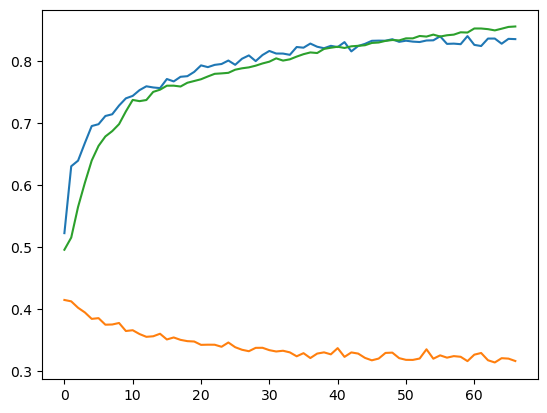

In [28]:
# plt.plot(history.history['accuracy'])
plt.plot(history.history['val_auc'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['auc'])

In [ ]:
# X_train_t = torch.from_numpy(X_train).float()
# y_train_t = torch.from_numpy(y_train).long()
# X_val_t = torch.from_numpy(X_val).float()
# y_val_t = torch.from_numpy(y_val).long()
# X_test_t = torch.from_numpy(X_test).float()
# y_test_t = torch.from_numpy(y_test).long()
n_classes = int(y.max()) + 1

In [ ]:
def evaluate_model(model, X, y, model_name="Model"):
    y_pred = np.argmax(model.predict(X, batch_size=512), axis=1)

    acc = np.mean(y_pred == y)
    print(f"\n=== {model_name} ===")
    print(f"Test Accuracy: {acc:.3f}\n")

    print("Classification Report:")
    print(classification_report(y, y_pred, digits=3))

    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)

    return acc, y_pred, cm

In [ ]:
mlp = load_model("mlp_best_model.keras")
#transformer = load_model("transformer_best_model.keras", custom_objects={'CLSToken': CLSToken, 'ExtractCLS': ExtractCLS})